# Team
- Stefanos Panteli UC1065916<br>
spante01@ucy.ac.cy

- Evangelia Krigkou UC1067400<br>
ekrigk01@ucy.ac.cy

- Rafael Chrysanthou UC1064747<br>
rchrys03@ucy.ac.cy


GitHub: [https://github.com/stefanosPanteli/EPL445](https://github.com/stefanosPanteli/EPL445)

# Installs

In [1]:
!pip install opencv-python
!pip install matplotlib
!pip install numpy

# Imports

In [2]:
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np
import skimage
import Huffman3
import collections
import os
import ast
import math

# 2. JPEG Encoding & Decoding

In [ ]:
class EncodeJPEG:
    # The Quantization table to divide all pixel values of a block
    q_table = np.array([
        [16, 11, 10, 16, 24,  40,  51,  61],
        [12, 12, 14, 19, 26,  58,  60,  55],
        [14, 13, 16, 24, 40,  57,  69,  56],
        [14, 17, 22, 29, 51,  87,  80,  62],
        [18, 22, 37, 56, 68,  109, 103, 77],
        [24, 35, 55, 64, 81,  104, 113, 92],
        [49, 64, 78, 87, 103, 121, 120, 101],
        [72, 92, 95, 98, 112, 100, 103, 99]
    ])
    # The Zig-Zag table to rearrange the block's values into a 1D array
    zig_zag_table = np.array([
        [0,  1,  5,  6,  14, 15, 27, 28],
        [2,  4,  7,  13, 16, 26, 29, 42],
        [3,  8,  12, 17, 25, 30, 41, 43],
        [9,  11, 18, 24, 31, 40, 44, 53],
        [10, 19, 23, 32, 39, 45, 52, 54],
        [20, 22, 33, 38, 46, 51, 55, 60],
        [21, 34, 37, 47, 50 ,56, 59, 61],
        [35, 36, 48, 49, 57, 58, 62, 63]
    ])

    def block_partition(self, I: cv2.Mat, block_size: int= 8):
        '''
        `block_partition` Breaks down the image I into `block_size` by `block_size` blocks.
        - `Args:`
            - `I: cv2.Mat`: The image to be partitioned.
                            The image should have a shape divisible by `block_size`.
            - `block_size: int = 8`: The size of the blocks. Default is 8.
        - `Returns:`
            - `vector_blocks: List[cv2.Mat]`: A list of partitioned blocks.
        '''
        vector_blocks = []
        iHeight, iWidth = I.shape
        for dim in I.shape:
            if dim % block_size != 0:
                raise ValueError(f'Image dimensions must be divisible by {block_size}')

        # Image partitioned into block_size x block_size blocks
        for startY in range(0, iHeight, block_size):
            for startX in range(0, iWidth, block_size):
                block = I[
                    # Take the block_size sized block
                    startY : startY + block_size,
                    startX : startX + block_size
                ]
                vector_blocks.append(block)

        return vector_blocks

    def dct(self, block: cv2.Mat):
      '''
      `dct` Applies the Discrete Cosine Transform to the block.
      - `Args:`
          - `block: cv2.Mat`: The block to be transformed.
      - `Returns:`
          - `cv2.Mat`: The DCT transformed block.
      '''
      # Apply DCT to the block casted to a float
      return cv2.dct(np.float32(block))

    def quantization(self, dct_block: cv2.Mat, factor: float):
      '''
      `quantization` Divides the pixel values of the block by the corresponding Q table value (multiplied by the factor).
      - `Args:`
          - `block: cv2.Mat`: The block to be quantized. The block should undergo DCT prior to quantization.
          - `factor: float`: The factor to multiply the Q table by.
      - `Returns:`
          - `cv2.Mat`: The quantized block.
      '''
      # Multiply the q_table by the factor and divide each pixel by the new q value
      q_table = np.multiply(self.q_table, factor)
      return np.floor(np.divide(dct_block, q_table) + 0.5).astype(np.int32)

    def rearrange_zig_zag(self, q_block: cv2.Mat, block_size: int= 8):
        '''
        `rearrange_zig_zag` Rearranges the block's values into a 1D array using the Zig-Zag table.
        - `Args:`
            - `block: cv2.Mat`: The block to be rearranged. The block should undergo quantization prior to rearranging.
            - `block_size: int = 8`: The size of the blocks. Default is 8.
        - `Returns:`
            - `zig_zag_sequence: np.ndarray`: The rearranged 1D array.
        '''
        if block_size != len(self.zig_zag_table):
            raise ValueError(f'Block size ({block_size}) and Zig-Zag Table size ({len(self.zig_zag_table)}) must agree.')

        zig_zag_sequence = np.zeros(block_size**2, dtype= q_block.dtype)

        # Populate the 1D array based on the zig_zag_table mapping
        for i in range(block_size):
            for j in range(block_size):
                zig_zag_sequence[self.zig_zag_table[i, j]] = q_block[i, j]

        return zig_zag_sequence

    def dpcm(self, vectors_zigzag: list[np.ndarray]):
        '''
        `dpcm` Applies the Differential Pulse Code Modulation to the DC compontents of the zig-zagged blocks.
        - `Args:`
            - `vectors_zigzag: list[np.ndarray]`: A list containing the zig-zagged 1D arrays.
        - `Returns:`
            - `e: list[float]`: A list containing the DC components after applying DPCM.
        '''
        e = []
        # leave first value of first vector as it is
        e.append(vectors_zigzag[0][0])
        for k in range(1, len(vectors_zigzag)):
            # Apply DPCM to the rest of the DC compontents
            e.append(vectors_zigzag[k][0] - vectors_zigzag[k - 1][0])

        return e

    def rlc(self, vectors_zigzag: list[np.ndarray]):
        '''
        `rlc` Applies the Run Length Coding to the AC compontents of the zig-zagged blocks.
        - `Args:`
            - `vectors_zigzag: list[np.ndarray]`: A list containing the zig-zagged 1D arrays.
        - `Returns:`
            - `to_return: list[list[tuple[int, float]]]`: A list containing the RLC results.
            > for each block: a list of (skip, value) tuples
        '''
        def _convert(block_ac_values: list[tuple[int, float]]):
            to_return = []
            zeroes = 0
            for i in range(len(block_ac_values)):
                # Count consecutive zeroes
                if block_ac_values[i] == 0:
                    zeroes += 1
                else:
                    # And append a (zeroes, next non-zero value)
                    to_return.append((zeroes, block_ac_values[i]))
                    # Reset the zero counter
                    zeroes = 0
            to_return.append((0, 0))
            return to_return

        return [
            # Conver all 1D blocks into RLC lists
            _convert(ac[1:])
            for ac in vectors_zigzag
        ]

    def huffman_encode(self, values: list):
        '''
        `huffman_encode` Encodes the values using Huffman encoding. The values could be either the DC or AC components.
        - `Args:`
            - `values: list`: A list containing the values to be encoded. Either floats for the DC, or tuples for the AC.
        - `Returns:`
            - `encoded_values: list`: A list containing the encoded values. A list of 0s and 1s.
            - `root: Huffman3.Node`: The root node of the Huffman tree.
        '''
        if not values:
            return [], None

        symbols_to_process = values
        # For the AC
        if values and isinstance(values[0], list) and values[0] and isinstance(values[0][0], tuple):
            processed_ac_symbols = []
            for sublist in values:
                for skip, val in sublist:
                    # Parse any possible (skip, value) tuple
                    if isinstance(val, (np.float32, np.float64, np.floating)):
                        processed_ac_symbols.append((skip, float(val)))
                    elif isinstance(val, (np.int32, np.int64, np.integer)):
                        processed_ac_symbols.append((skip, int(val)))
                    else:
                        processed_ac_symbols.append((skip, val))
            symbols_to_process = processed_ac_symbols
        # For the DC, just making sure they are all floats
        elif all(isinstance(val, (int, float, np.integer, np.floating)) for val in values):
            symbols_to_process = [float(val) for val in values]

        # Compute the percentages
        counter = collections.Counter(symbols_to_process)
        probs = [(key, np.float32(value)) for key, value in counter.items()]
        # Run the Huffman encoding
        symbols = Huffman3.makenodes(probs)
        root = Huffman3.iterate(symbols)
        return Huffman3.encode(symbols_to_process, symbols), root

    def encode(self, I: cv2.Mat, factor: float, block_size: int= 8):
        '''
        `encode` Encodes the image I using JPEG encoding.
        - `Args:`
            - `I: cv2.Mat`: The image to be encoded.
            - `factor: float`: The quantization factor.
        - `Returns:`
            - `dc_symbols: list`: A list containing the encoded DC values.
            - `dc_root: Huffman3.Node`: The root node of the DC Huffman tree.
            - `ac_symbols: list`: A list containing the encoded AC values.
            - `ac_root: Huffman3.Node`: The root node of the AC Huffman tree.
        '''
        blocks = self.block_partition(I, block_size)
        dct_blocks = [self.dct(block) for block in blocks]
        q_blocks = [self.quantization(block, factor) for block in dct_blocks]
        zig_blocks = [self.rearrange_zig_zag(block, block_size) for block in q_blocks]

        dc_components = self.dpcm(zig_blocks)
        ac_components = self.rlc(zig_blocks)

        dc_symbols, dc_root = self.huffman_encode(dc_components)
        ac_symbols, ac_root = self.huffman_encode(ac_components)

        return (dc_symbols, dc_root, ac_symbols, ac_root)

In [ ]:
class DecodeJPEG:
    # The Quantization table to multiply all pixel values of a block
    q_table = np.array([
        [16, 11, 10, 16, 24,  40,  51,  61],
        [12, 12, 14, 19, 26,  58,  60,  55],
        [14, 13, 16, 24, 40,  57,  69,  56],
        [14, 17, 22, 29, 51,  87,  80,  62],
        [18, 22, 37, 56, 68,  109, 103, 77],
        [24, 35, 55, 64, 81,  104, 113, 92],
        [49, 64, 78, 87, 103, 121, 120, 101],
        [72, 92, 95, 98, 112, 100, 103, 99]
    ])
    # The Zig-Zag table to rearrange the block's values from a 1D array to 2D
    zig_zag_table = np.array([
        [0,  1,  5,  6,  14, 15, 27, 28],
        [2,  4,  7,  13, 16, 26, 29, 42],
        [3,  8,  12, 17, 25, 30, 41, 43],
        [9,  11, 18, 24, 31, 40, 44, 53],
        [10, 19, 23, 32, 39, 45, 52, 54],
        [20, 22, 33, 38, 46, 51, 55, 60],
        [21, 34, 37, 47, 50, 56, 59, 61],
        [35, 36, 48, 49, 57, 58, 62, 63]
    ])

    def huffman_decode(self, encoded_values: list, root):
        '''
        `huffman_decode` Decodes the values using Huffman decoding.
        - `Args:`
            - `encoded_values: list`: A list containing the encoded values. A list of 0s and 1s.
            - `root: Huffman3.Node`: The root node of the Huffman tree.
        - `Returns:`
            - `decoded_values: list`: A list containing the decoded values.
        '''
        return Huffman3.decode(encoded_values, root)

    def inv_dpcm(self, dc_values):
        '''
        `inv_dpcm` Applies the Inverse Differential Pulse Code Modulation to the DC compontents of the blocks.
        - `Args:`
            - `dc_values: list`: A list containing the DC values
        - `Returns:`
            - `decoded_dc: list`: A list containing the decoded DC values.
        '''
        if not dc_values:
            return []
        # The first value remains intact
        decoded_dc = [dc_values[0]]
        # The rest are added sequentially
        for i in range(1, len(dc_values)):
            decoded_dc.append(dc_values[i] + decoded_dc[i - 1])

        return decoded_dc

    def inv_rlc(self, rlc_tuples_as_strings: list, block_size: int= 8):
        '''
        `inv_rlc` Applies the Inverse Run Length Coding to the AC compontents of the blocks.
        - `Args:`
            - `rlc_tuples_as_strings: list`: A list containing the RLC tuples as strings.
            - `block_size: int = 8`: The size of the blocks. Default is 8.
        - `Returns:`
            - `all_ac_blocks: list`: A list containing the decoded AC blocks.
        '''
        all_ac_blocks = []
        current_block_ac = []

        total_ac_components = block_size ** 2 - 1

        for tuple_string in rlc_tuples_as_strings:
            # Literally evaluate the string tuple to a real tuple
            skip, value = ast.literal_eval(tuple_string)

            # If both values are 0, means the end of the block
            if skip == 0 and value == 0:  # EOB
                # Pad it with the remaining 0s
                if len(current_block_ac) < total_ac_components:
                    current_block_ac.extend([0] * (total_ac_components - len(current_block_ac)))
                all_ac_blocks.append(current_block_ac)
                # Reset
                current_block_ac = []
            else:
                # Fill in skip amount of 0 and the value after
                current_block_ac.extend([0] * skip)
                current_block_ac.append(value)

        # For the last remaining block
        if current_block_ac:
            if len(current_block_ac) < total_ac_components:
                current_block_ac.extend([0] * (total_ac_components - len(current_block_ac)))
            all_ac_blocks.append(current_block_ac)

        return all_ac_blocks

    def combine(self, dc_values: list, ac_values_rlc_decoded: list, block_size: int= 8):
        '''
        `combine` Combines the DC and AC components of the blocks into blocks.
        - `Args:`
            - `dc_values: list`: A list containing the DC values.
            - `ac_values_rlc_decoded: list`: A list containing the decoded AC values.
            - `block_size: int = 8`: The size of the blocks. Default is 8.
        - `Returns:`
            - `blocks: list`: A list containing the combined blocks.
        '''
        blocks = []
        n = min(len(dc_values), len(ac_values_rlc_decoded))

        total_ac_components = block_size ** 2 - 1

        # For each value to combine
        for i in range(n):
            # Get the list containing the AC compontents
            ac_block = list(ac_values_rlc_decoded[i])
            # Pad if necessary
            if len(ac_block) < total_ac_components:
                ac_block.extend([0] * (total_ac_components - len(ac_block)))
            # Add the DC in the front, as a 1D array
            blocks.append([dc_values[i]] + ac_block[:total_ac_components])

        return blocks

    def inv_zig_zag(self, block_1d: list, block_size: int= 8):
        '''
        `inv_zig_zag` Rearranges the block's values from a 1D array to 2D using the Zig-Zag table.
        - `Args:`
            - `block_1d: list`: A list containing the 1D block.
            - `block_size: int = 8`: The size of the blocks. Default is 8.
        - `Returns:`
            - `block_2d: np.ndarray`: The rearranged 2D block.
        '''
        if block_size != len(self.zig_zag_table):
            raise ValueError(f'Block size ({block_size}) and Zig-Zag Table size ({len(self.zig_zag_table)}) must agree.')

        # Initialize the 2D block
        block_2d = np.zeros((block_size, block_size), dtype= np.float32)

        for r in range(block_size):
            for c in range(block_size):
                # Add the value of the 1D array to the corresponding indez in the 2D array
                block_2d[r, c] = block_1d[self.zig_zag_table[r, c]]

        return block_2d

    def inv_quantization(self, block: cv2.Mat, factor: float):
        '''
        `inv_quantization` Multiplies the pixel values of the block by the corresponding Q table value (multiplied by the factor).
        - `Args:`
            - `block: cv2.Mat`: The block to be quantized.
            - `factor: float`: The factor to multiply the Q table by.
        - `Returns:`
            - `cv2.Mat`: The quantized block.
        '''
        # Multiply the Q values by the factor
        q_table = np.multiply(self.q_table, factor)
        # Multiply each value with the corresponding Q value
        return np.multiply(block, q_table).astype(np.float32)

    def inv_dct(self, block: cv2.Mat):
        '''
        `inv_dct` Applies the Inverse Discrete Cosine Transform to the block.
        - `Args:`
            - `block: cv2.Mat`: The block to be transformed.
        - `Returns:`
            - `cv2.Mat`: The DCT transformed block.
        '''
        return cv2.idct(np.float32(block))

    def merge_blocks(self, blocks: list[cv2.Mat], original_shape: tuple, block_size: int= 8):
        '''
        `merge_blocks` Merges the blocks into a single image.
        - `Args:`
            - `blocks: list`: A list containing the blocks.
            - `original_shape: tuple`: The shape of the original image.
            - `block_size: int = 8`: The size of the blocks. Default is 8.
        - `Returns:`
            - `merged_image: np.ndarray`: The merged image.
        '''
        if not blocks:
            return np.zeros(original_shape, dtype=np.uint8)
        # Init image
        height, width = original_shape
        merged_image = np.zeros((height, width), dtype=blocks[0].dtype)

        # Copy each image to the corresponding position
        block_idx = 0
        for i in range(0, height, block_size):
            for j in range(0, width, block_size):
                if block_idx < len(blocks):
                    merged_image[
                        i : i + block_size,
                        j : j + block_size
                    ] = blocks[block_idx]
                    block_idx += 1

        return merged_image

    def bound(self, I: cv2.Mat):
        '''
        `bound` Bounds the values of the image to the range [0, 255].
        - `Args:`
            - `I: cv2.Mat`: The image to be bounded.
        - `Returns:`
            - `np.uint8(I)`: The bounded image.
        '''
        I = I.copy()
        np.place(I, I > 255.0, 255.0)
        np.place(I, I < 0.0, 0.0)
        return np.uint8(I)

    def decode(self, dc_encoded: list, dc_root, ac_encoded: list, ac_root, factor: float, original_shape: tuple, block_size: int= 8):
        '''
        `decode` Decodes the image using JPEG encoding.
        - `Args:`
            - `dc_encoded: list`: A list containing the encoded DC values.
            - `dc_root: Huffman3.Node`: The root node of the DC Huffman tree.
            - `ac_encoded: list`: A list containing the encoded AC values.
            - `ac_root: Huffman3.Node`: The root node of the AC Huffman tree.
            - `factor: float`: The quantization factor.
            - `original_shape: tuple`: The shape of the original image.
            - `block_size: int = 8`: The size of the blocks. Default is 8.
        - `Returns:`
            - `reconstructed: np.ndarray`: The reconstructed image.
        '''
        decoded_dc_values = self.huffman_decode(dc_encoded, dc_root)
        decoded_ac_tuples = self.huffman_decode(ac_encoded, ac_root)

        decoded_dc_values = [float(x) for x in decoded_dc_values]

        dc_components = self.inv_dpcm(decoded_dc_values)
        ac_components = self.inv_rlc(decoded_ac_tuples, block_size)

        combined_blocks_1d = self.combine(dc_components, ac_components, block_size)
        inv_zig_zag_blocks = [self.inv_zig_zag(block, block_size) for block in combined_blocks_1d]
        inv_quantized_blocks = [self.inv_quantization(block, factor) for block in inv_zig_zag_blocks]
        inv_dct_blocks = [self.inv_dct(block) for block in inv_quantized_blocks]

        reconstructed = self.merge_blocks(inv_dct_blocks, original_shape, block_size)
        return self.bound(reconstructed)

# 1

Original Shape: (579, 750)
Cropped Shape: (576, 744)


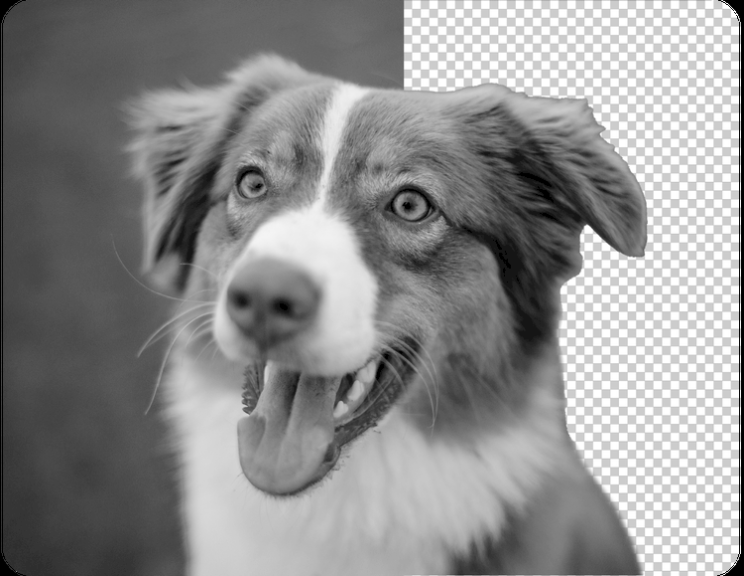

In [5]:
image = cv2.imread('input/dog.png', 0)
print('Original Shape:', image.shape)
# Resize so it is a multiple of 8
image = cv2.resize(image, (image.shape[1] // 8 * 8, image.shape[0] // 8 * 8))
print('Cropped Shape:', image.shape)
cv2_imshow(image)

# 3

In [6]:
q_factors = [0.5, 1, 2] + [5, 10, 20]

# 4

In [ ]:
def compute_metrics(I, comp_I, in_path, out_path):
  MSE = skimage.metrics.mean_squared_error(I, comp_I)
  PSNR = skimage.metrics.peak_signal_noise_ratio(I, comp_I)
  SSIM = skimage.metrics.structural_similarity(I, comp_I, data_range= comp_I.max() - comp_I.min())
  CR = os.path.getsize(in_path) / os.path.getsize(out_path)
  return {
    'MSE': round(float(MSE), 2),
    'PSNR': round(float(PSNR), 2),
    'SSIM': round(float(SSIM), 2),
    'CR': round(float(CR), 2)
  }

# 5 & 6

MSE: 5.64
PSNR: 40.62
SSIM: 0.98
CR: 6.89


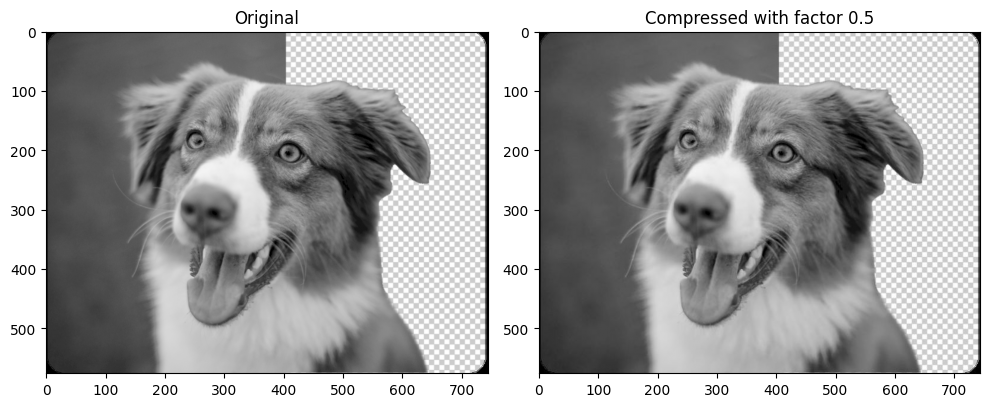


MSE: 10.25
PSNR: 38.02
SSIM: 0.97
CR: 8.06


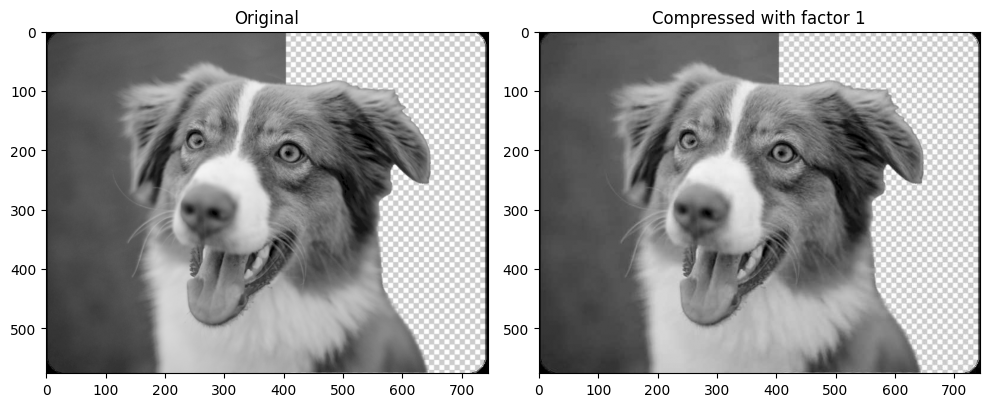


MSE: 19.82
PSNR: 35.16
SSIM: 0.94
CR: 9.77


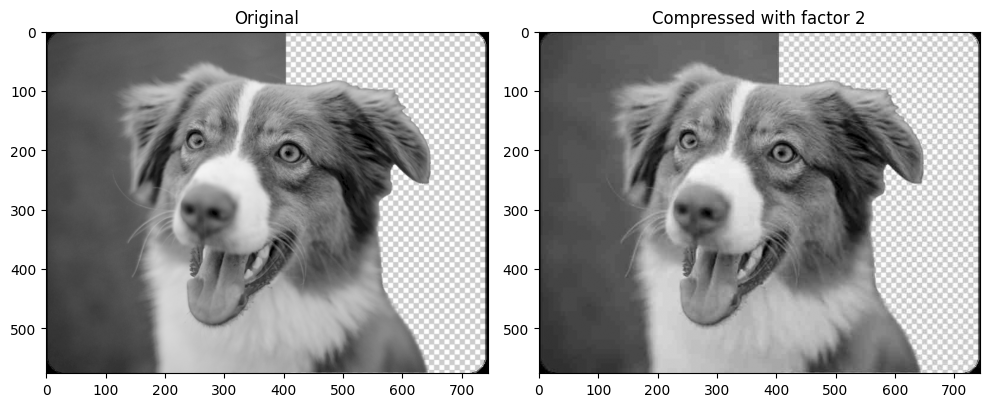


MSE: 56.2
PSNR: 30.63
SSIM: 0.87
CR: 13.45


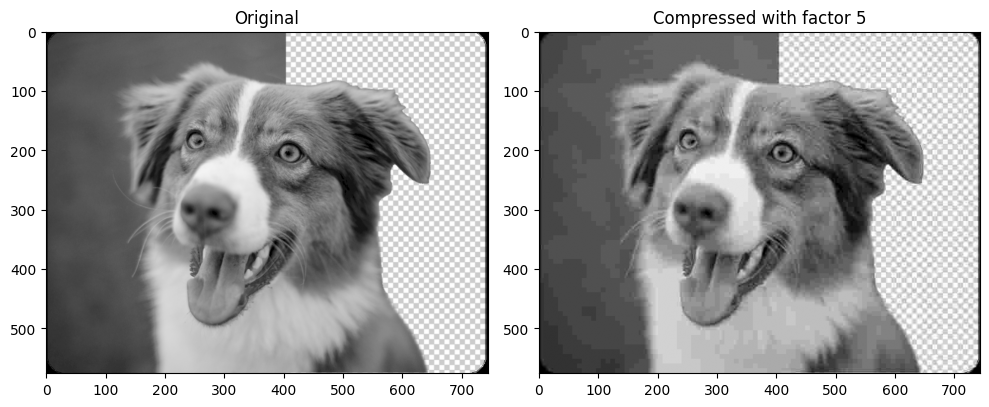


MSE: 117.49
PSNR: 27.43
SSIM: 0.78
CR: 19.73


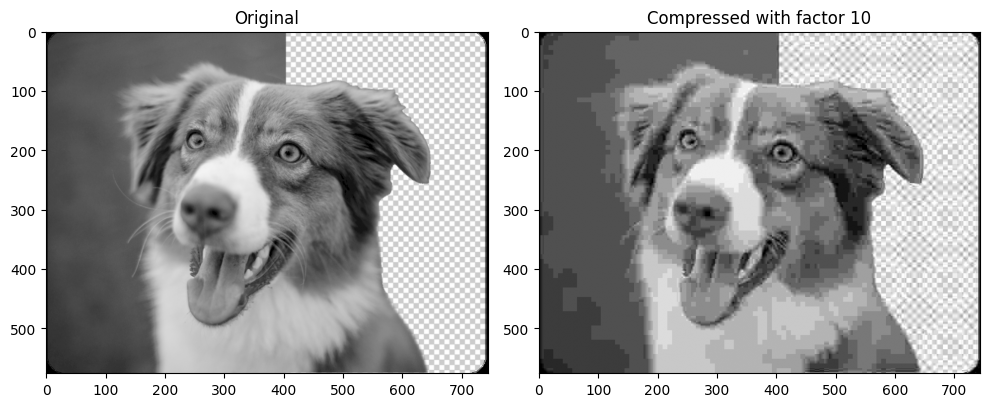


MSE: 308.98
PSNR: 23.23
SSIM: 0.68
CR: 33.24


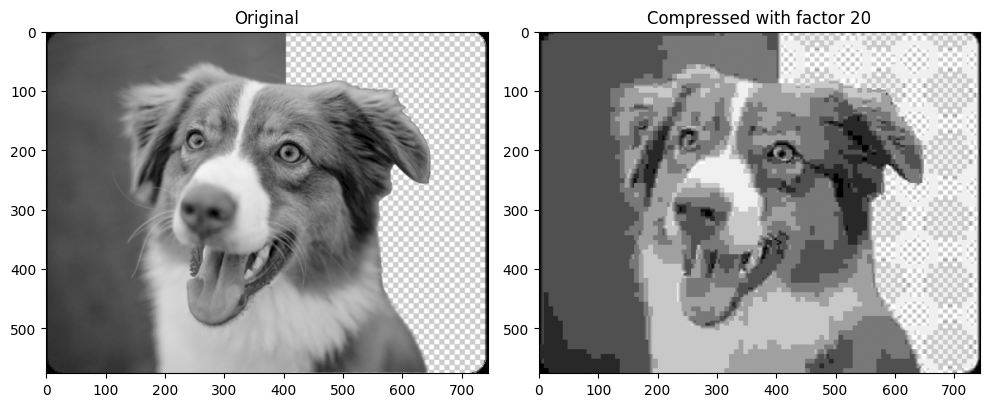

In [ ]:
if not os.path.exists('output'):
    os.makedirs('output')

def _plot(I, comp_I, factor):
    plt.figure(figsize=(10, 10))
    plt.subplot(121)
    plt.title(f'Original')
    plt.imshow(I, cmap= 'gray')
    plt.subplot(122)
    plt.title(f'Compressed with factor {factor}')
    plt.imshow(comp_I, cmap= 'gray')
    plt.tight_layout()
    plt.show()

metrics = {}
for factor in q_factors:
    components = EncodeJPEG().encode(image, factor)
    comp_I = DecodeJPEG().decode(*components, factor, image.shape)

    cv2.imwrite(f'output/compressed_{factor}.jpg', comp_I)
    metrics[factor] = compute_metrics(image, comp_I, 'input/dog.png', f'output/compressed_{factor}.jpg')
    for metric, value in metrics[factor].items():
        print(f'{metric}: {value}')
    _plot(image, comp_I, factor)

    print()

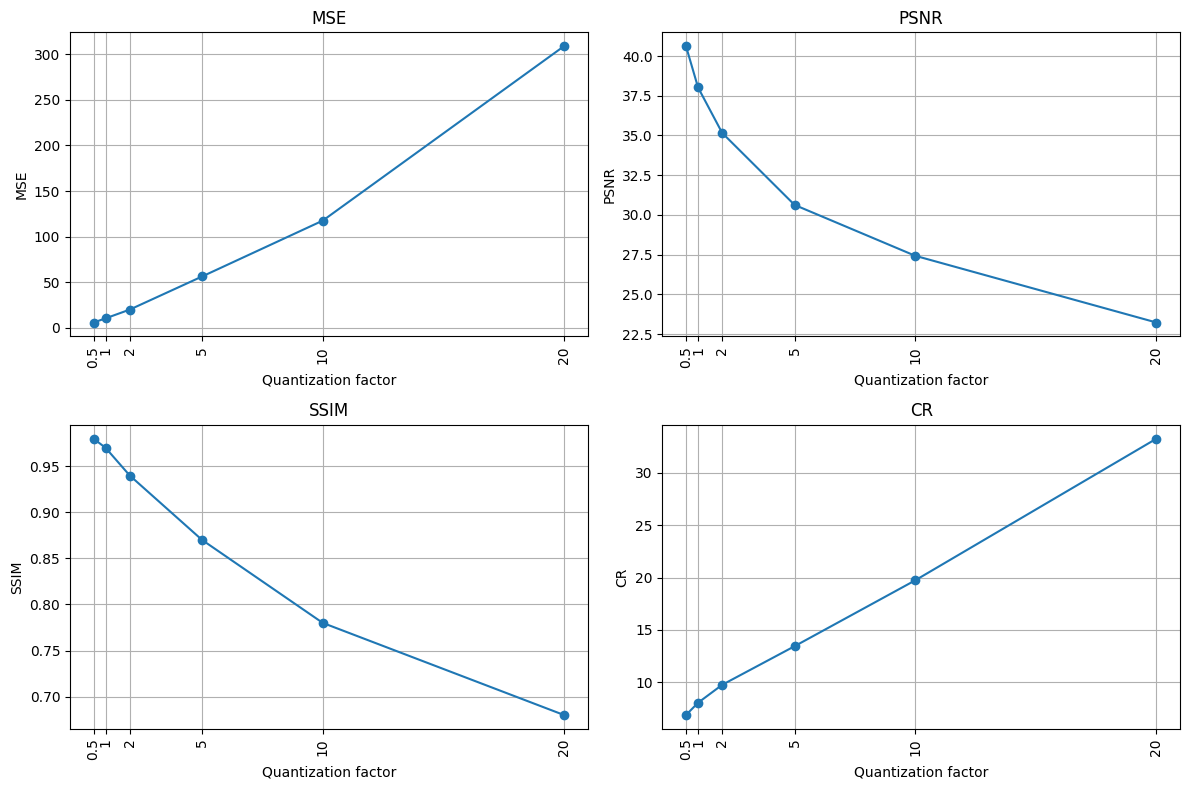

In [9]:
metric_names = list(metrics[q_factors[0]].keys())
n_metrics = len(metric_names)

ncols = 2
nrows = math.ceil(n_metrics / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), sharex= False)
axes = np.array(axes).reshape(-1)

for i, metric in enumerate(metric_names):
    y_values = [metrics[factor][metric] for factor in q_factors]
    axes[i].plot(q_factors, y_values, marker='o')
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].grid(True)

# Hide unused subplots
for j in range(len(metric_names), len(axes)):
    axes[j].axis('off')

for ax in axes:
    ax.set_xlabel('Quantization factor')
    ax.set_xticks(q_factors)
    ax.set_xticklabels([str(factor) for factor in q_factors], rotation=90)

plt.tight_layout()
plt.show()